# Raw Data Exploration — Phase 1

Queries `raw.activity_cdc` directly, upstream of any dbt model, and asks: **are there signals in the raw events that the current feature pipeline isn't capturing?**

See [docs/feature-exploration.md](../docs/feature-exploration.md) for how this fits into the two-phase feature-exploration workflow and when it's triggered.

**Prerequisites**
```bash
gcloud auth application-default login
uv sync --package trainer --extra dev
```

This notebook only reads from BigQuery — nothing here touches `projects/dbt_transform/` or Terraform. The output is a written list of candidate engineering requests, not code.

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
BQ_RAW_TABLE      = "raw.activity_cdc"
BQ_FEATURES_TABLE = "features.customer_features"   # only used for the gap analysis in step 5
SAMPLE_LIMIT      = 200_000              # event-level sample for correlation/MI; aggregations below query the full table
RANDOM_STATE      = 42

In [ ]:
import google.auth
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.cloud import bigquery
from scipy.stats import pointbiserialr
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

# picked up from the active `gcloud auth application-default login` / `gcloud config set project` context
_, GCP_PROJECT = google.auth.default()
bq = bigquery.Client(project=GCP_PROJECT)
print(f"BigQuery client ready — using GCP project: {GCP_PROJECT}")

## 1. Event type distribution

Counts each `event_type` over the *full* table (server-side aggregation, not the sample below) and its churn rate. A rare event type can carry disproportionate churn signal even though it barely moves `total_events`.

In [3]:
event_dist = bq.query(f"""
    SELECT
        event_type,
        COUNT(*)                                    AS n_events,
        SAFE_DIVIDE(COUNT(*), SUM(COUNT(*)) OVER ()) AS share_of_events,
        SAFE_DIVIDE(COUNTIF(churned), COUNT(*))      AS churn_rate
    FROM `{GCP_PROJECT}.{BQ_RAW_TABLE}`
    WHERE NOT COALESCE(anomaly_injected, FALSE)
    GROUP BY event_type
    ORDER BY n_events DESC
""").to_dataframe()

event_dist["rare"] = event_dist["share_of_events"] < 0.05
event_dist

,event_type,n_events,share_of_events,churn_rate,rare
0,campaign_action,3598,0.149917,0.153419,False
1,event_attended,3448,0.143667,0.151972,False
2,membership_cancelled,3431,0.142958,0.158554,False
3,email_engagement,3402,0.141750,0.154321,False
4,transaction,3393,0.141375,0.145004,False
5,membership_renewal,3372,0.140500,0.153025,False
6,contact_request,3356,0.139833,0.143027,False


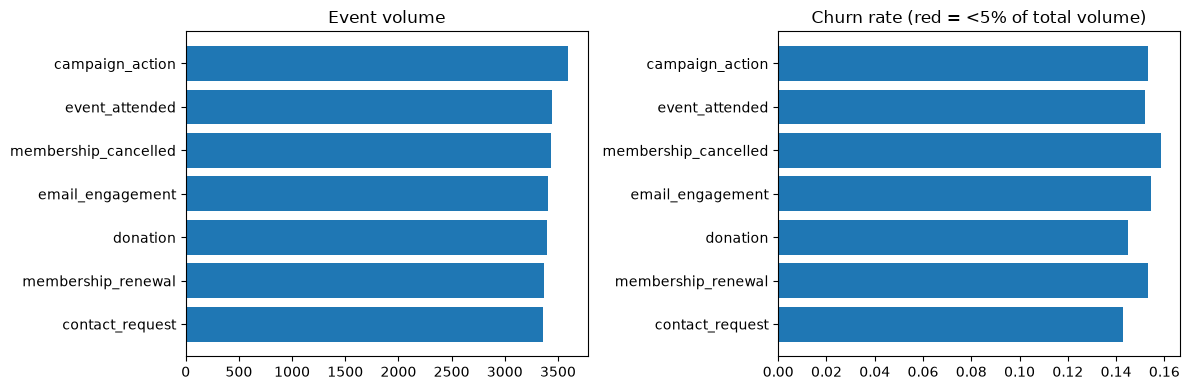

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(event_dist["event_type"], event_dist["n_events"])
axes[0].set_title("Event volume")
axes[0].invert_yaxis()

colors = ["tab:red" if r else "tab:blue" for r in event_dist["rare"]]
axes[1].barh(event_dist["event_type"], event_dist["churn_rate"], color=colors)
axes[1].set_title("Churn rate (red = <5% of total volume)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 2. Raw field correlations with churn (event level)

Pulls a deduplicated, anomaly-filtered event sample and measures how strongly each raw field relates to `churned` *before* any dbt aggregation.

- **Numeric fields** use point-biserial correlation — the correct test when the outcome is binary and the predictor is continuous; it's mathematically equivalent to Pearson's r on a 0/1-coded variable.
- **Categorical fields** use mutual information instead of, say, Cramér's V or chi-square. MI captures any nonlinear/non-monotonic dependence without imposing an ordinal assumption on nominal categories like `region` or `channel` — a correlation coefficient would silently depend on whatever arbitrary numeric order the encoder assigns.

In [5]:
sample_df = bq.query(f"""
    SELECT
        event_type, region, membership_tier, monthly_transaction, payment_status,
        payment_attempts_last_30d, engagement_score, member_since_days,
        contact_requests_last_30d, channel, churned
    FROM (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY event_id ORDER BY event_timestamp DESC) AS _rn
        FROM `{GCP_PROJECT}.{BQ_RAW_TABLE}`
        WHERE NOT COALESCE(anomaly_injected, FALSE)
    )
    WHERE _rn = 1
    ORDER BY RAND()
    LIMIT {SAMPLE_LIMIT}
""").to_dataframe()
# NB: ORDER BY RAND() over a huge table gets expensive — swap for TABLESAMPLE SYSTEM (n PERCENT)
# if activity_cdc grows past what a full shuffle can handle.

print(f"Sampled {len(sample_df):,} deduplicated events")
sample_df.head()

Sampled 24,000 deduplicated events


,event_type,region,membership_tier,monthly_transaction,payment_status,payment_attempts_last_30d,engagement_score,member_since_days,contact_requests_last_30d,channel,churned
0,email_engagement,eu-central,friend,30.59,success,2,0.2057,2990,1,email,False
1,email_engagement,us-east,guardian,90.16,failed,4,NaN,1790,0,direct_mail,False
2,contact_request,latam,friend,27.38,success,1,NaN,3260,2,direct_mail,False
3,event_attended,latam,guardian,110.09,pending,1,NaN,<NA>,0,phone,False
4,event_attended,us-east,supporter,10.81,pending,3,0.0741,602,0,web,False


In [6]:
y = sample_df["churned"].astype(int)

numeric_fields = [
    "monthly_transaction", "payment_attempts_last_30d",
    "engagement_score", "member_since_days", "contact_requests_last_30d",
]

pb_rows = []
for col in numeric_fields:
    mask = sample_df[col].notna()
    r, p = pointbiserialr(sample_df.loc[mask, col], y[mask])
    pb_rows.append({"field": col, "point_biserial_r": r, "p_value": p, "n": int(mask.sum())})

pb_df = pd.DataFrame(pb_rows).sort_values("point_biserial_r", key=np.abs, ascending=False)
pb_df

,field,point_biserial_r,p_value,n
2,engagement_score,-0.158791,8.432377e-91,15992
3,member_since_days,-0.004961,4.488011e-01,23316
1,payment_attempts_last_30d,0.004316,5.037505e-01,24000
0,monthly_transaction,-0.003788,5.573747e-01,24000
4,contact_requests_last_30d,0.000456,9.436272e-01,24000


In [7]:
categorical_fields = ["event_type", "region", "membership_tier", "payment_status", "channel"]

encoded = OrdinalEncoder().fit_transform(sample_df[categorical_fields].astype(str))
mi_scores = mutual_info_classif(encoded, y, discrete_features=True, random_state=RANDOM_STATE)

mi_df = pd.DataFrame({"field": categorical_fields, "mutual_info": mi_scores}).sort_values(
    "mutual_info", ascending=False
)
mi_df

,field,mutual_info
4,channel,0.020796
1,region,0.000208
0,event_type,0.000098
3,payment_status,0.000053
2,membership_tier,0.000029


## 3. Cohort breakdowns

Cross-tabulates churn rate by single cohort dimensions, then by a `membership_tier` × `channel` pair to check for an interaction effect that no single scalar feature (like `preferred_channel` alone) can express.

In [8]:
for dim in ["membership_tier", "region", "channel"]:
    rate = sample_df.groupby(dim)["churned"].mean().sort_values(ascending=False)
    print(f"\nChurn rate by {dim}:")
    print(rate.to_string(float_format=lambda x: f"{x:.1%}"))


Churn rate by membership_tier:
membership_tier
friend      15.4%
supporter   15.4%
guardian    14.9%
champion    14.8%

Churn rate by region:
region
latam        16.6%
us-east      15.5%
us-west      14.9%
apac         14.8%
eu-west      14.7%
eu-central   14.3%

Churn rate by channel:
channel
direct_mail   26.3%
phone         25.2%
mobile        10.2%
web            9.9%
email          9.8%
in_person      9.4%


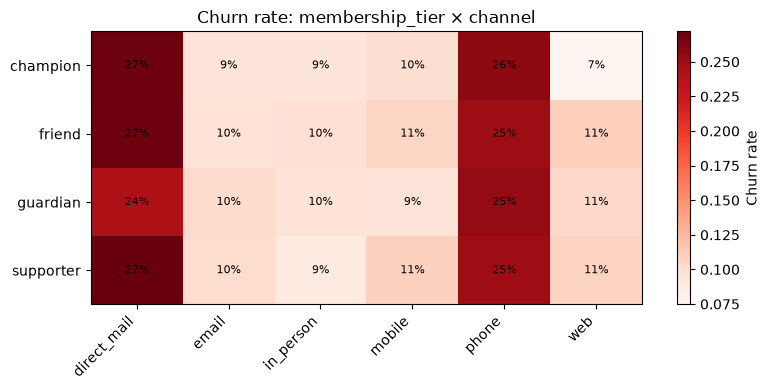

In [9]:
pivot = sample_df.assign(churned=sample_df["churned"].astype(int)).pivot_table(
    index="membership_tier", columns="channel", values="churned", aggfunc="mean"
)

plt.figure(figsize=(8, 4))
plt.imshow(pivot, cmap="Reds", aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Churn rate")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        plt.text(j, i, f"{pivot.iloc[i, j]:.0%}", ha="center", va="center", fontsize=8)
plt.title("Churn rate: membership_tier × channel")
plt.tight_layout()
plt.show()

## 4. Time-series patterns

Rolling churn rate vs. event volume over time, aggregated server-side by day, to catch seasonality or a trend that a single training snapshot won't reveal.

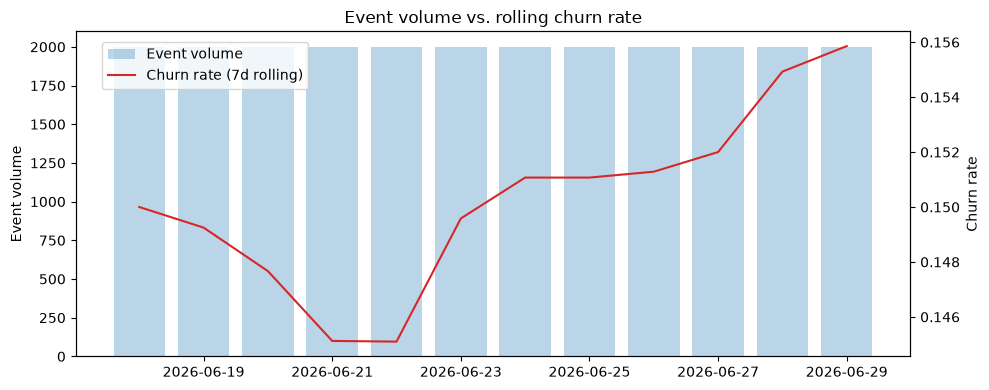

In [10]:
ts_df = bq.query(f"""
    SELECT
        DATE(event_timestamp)                   AS event_date,
        COUNT(*)                                 AS n_events,
        SAFE_DIVIDE(COUNTIF(churned), COUNT(*))  AS churn_rate
    FROM `{GCP_PROJECT}.{BQ_RAW_TABLE}`
    WHERE NOT COALESCE(anomaly_injected, FALSE)
    GROUP BY event_date
    ORDER BY event_date
""").to_dataframe()

ts_df["churn_rate_7d"] = ts_df["churn_rate"].rolling(7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(ts_df["event_date"], ts_df["n_events"], alpha=0.3, label="Event volume")
ax1.set_ylabel("Event volume")

ax2 = ax1.twinx()
ax2.plot(ts_df["event_date"], ts_df["churn_rate_7d"], color="tab:red", label="Churn rate (7d rolling)")
ax2.set_ylabel("Churn rate")

fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.title("Event volume vs. rolling churn rate")
plt.tight_layout()
plt.show()

## 5. Gap analysis

Diffs the raw schema against the engineered feature matrix via `INFORMATION_SCHEMA`, so the comparison stays correct even after the dbt models change — it's re-derived from BigQuery metadata, not hand-copied from docs.

A raw field with no identically-named column in `customer_features` isn't automatically a gap: some are captured under a different name (`channel` → `preferred_channel`) or only partially captured (`event_type` → `renewal_count` + `campaign_participation_rate`, which together ignore every other event type). The `captured_as` column below makes that judgment call explicit instead of leaving it implicit.

In [11]:
raw_cols = bq.query(f"""
    SELECT column_name FROM `{GCP_PROJECT}.raw.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name = 'activity_cdc'
""").to_dataframe()["column_name"].tolist()

engineered_cols = bq.query(f"""
    SELECT column_name FROM `{GCP_PROJECT}.features.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name = 'customer_features'
""").to_dataframe()["column_name"].tolist()

captured_as = {
    "event_id":                  "metadata — not a feature candidate",
    "event_timestamp":           "superseded by latest_event_ts",
    "raw_payload":               "metadata — not a feature candidate",
    "anomaly_injected":          "metadata — filtering flag only",
    "monthly_transaction":          "avg_transaction_30d / avg_transaction_90d",
    "engagement_score":          "avg_engagement_30d / avg_engagement_90d",
    "channel":                   "preferred_channel (mode only — per-event switching is lost)",
    "payment_status":            "payment_failure_rate_30d / 90d (captures 'failed' only, not 'pending')",
    "payment_attempts_last_30d": "total_payment_attempts (summed, not per-window)",
    "event_type":                "PARTIAL — renewal_count and campaign_participation_rate only; "
                                  "membership_cancelled and contact_request event counts are not engineered",
}

gaps = sorted(set(raw_cols) - set(engineered_cols))
gap_df = pd.DataFrame({
    "raw_field": gaps,
    "captured_as": [captured_as.get(f, "NO ENGINEERED COUNTERPART FOUND") for f in gaps],
})
gap_df

,raw_field,captured_as
0,anomaly_injected,metadata — filtering flag only
1,channel,preferred_channel (mode only — per-event switc...
2,engagement_score,avg_engagement_30d / avg_engagement_90d
3,event_id,metadata — not a feature candidate
4,event_timestamp,superseded by latest_event_ts
5,event_type,PARTIAL — renewal_count and campaign_participa...
6,monthly_transaction,avg_transaction_30d / avg_transaction_90d
7,payment_attempts_last_30d,"total_payment_attempts (summed, not per-window)"
8,payment_status,payment_failure_rate_30d / 90d (captures 'fail...
9,raw_payload,metadata — not a feature candidate


## Output — candidate feature requests

Talking-point summary for the engineering request `docs/feature-exploration.md`'s Phase 1 output asks this notebook to produce. Fill in real numbers from the cells above before treating any of these as final — "add a feature for X" without a correlation, MI score, or churn-rate delta attached to it is not something you can defend in an interview.

Candidates worth writing up as concrete engineering requests, based on the structure above:

1. **Count of `membership_cancelled` events in the trailing 14/30 days** — the gap analysis shows this event type has no engineered counterpart at all; check its `churn_rate` and `share_of_events` from step 1 before requesting it (a rare-but-highly-correlated event beats a common-but-neutral one).
2. **Count/rate of `contact_request` events** — distinct from the pass-through `contact_requests_last_30d` field; if its MI/point-biserial signal (step 2) differs meaningfully from that pass-through field, that's evidence the raw event stream carries something the pre-aggregated field doesn't.
3. **`payment_status = 'pending'` rate**, not just `failed` — the current `payment_failure_rate_*` columns collapse `pending` into "not failed". If step 2's MI for `payment_status` is high, check whether `pending` alone is driving it.
4. **Event-type diversity/entropy per customer** — the tier × channel interaction (step 3) and the gap analysis both suggest scalar aggregates lose behavioral variety; a Shannon entropy over a customer's `event_type` distribution is a cheap way to recover some of it.
5. **Rolling/seasonal indicator** — only worth requesting if step 4's time-series plot shows a real trend or seasonality, not just noise.

## Next steps

Once a candidate is confirmed with real numbers, hand it to the data engineer as a request against `projects/dbt_transform/models/intermediate/int_customer_aggregates.sql` (new column) and `iac/config/bigquery.yaml` (schema entry) — this notebook does not modify dbt or Terraform itself.

See [docs/feature-exploration.md](../docs/feature-exploration.md) for the full promotion path, and run `notebooks/feature_selection.ipynb` next to check whether the *existing* feature set is still earning its place.